# Analytics Project:

## Finding Your Fit
### Predicting the Right Physical Activity for Young Adults Through Behavioral Profiling


##### Aicha Dieng



# Introduction

In Japan, corporate wellness is not optional; it is institutional.
Companies are evaluated under a national health management framework
that holds employers accountable for the physical wellbeing of their
workforce. Organizations whose employees fall below health benchmarks
face higher insurance premiums and reputational consequences. As a
result, keeping employees active is not just an HR initiative; it is
a business imperative.

This project is framed around a Japanese multinational company looking
to implement a personalized employee wellness program across its
international offices. The challenge is straightforward: not everyone
moves the same way, and not everyone wants to. A blanket "go exercise"
policy produces low participation and poor results. What works is
meeting people where they are, recommending the activity that fits
their body, their lifestyle, and their habits.

This is what this model does. Given an employee's basic health metrics
and behavioral patterns, it identifies what type of mover they are and
recommends the physical activity: Running, Swimming, or Weight
Training is most suited to their profile. The goal is not to force
participation, but to lower the barrier to it by making the first
recommendation feel personal and achievable.

### Why This Population

The analysis focuses on adults aged 18 to 30. This is the age group
most likely to be entering the workforce for the first time, and
statistically the window where long-term exercise habits are either
formed or abandoned. Getting this group moving consistently and in
the right direction has compounding benefits over time.

### Data

The dataset used is FitLife360, sourced from Kaggle. It is a synthetic
health and fitness tracking dataset simulating one year of activity
data across 3,000 participants. Each row represents a single workout
session and captures demographic information, workout metrics,
lifestyle indicators, and health vitals.

The full dataset contains 687,701 sessions. For this analysis, the
data was filtered to adults aged 18 to 30 who engage in one of three
activities: **Running, Swimming, or Weight Training**. This produced a
working subset of 52,557 sessions across the target population.

### Analytical Approach

The project combines two methods. First, unsupervised clustering
(KMeans) is used to discover natural behavioral profiles among the
participants without any predefined labels. Three profiles emerged
from this step.

 Second, supervised classification (Decision Tree) is
used to predict which activity type best matches a person's profile,
using the cluster label as one of the input features.

This two-step approach reflects a real intake process: first
understand who the person is, then make a recommendation based on
that understanding.

- Kaggle Link : https://www.kaggle.com/datasets/jijagallery/fitlife-health-and-fitness-tracking-dataset


In [ ]:
import kagglehub

path = kagglehub.dataset_download("jijagallery/fitlife-health-and-fitness-tracking-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fitlife-health-and-fitness-tracking-dataset' dataset.
Path to dataset files: /kaggle/input/fitlife-health-and-fitness-tracking-dataset


In [ ]:
import pandas as pd
import os

print(os.listdir(path))

['health_fitness_dataset.csv']


In [ ]:
df = pd.read_csv(path + "/health_fitness_dataset.csv")
print(df.shape)
df.head()

(687701, 22)


,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33


# Data Preparation

In [ ]:
df.isna().sum()

,0
participant_id,0
date,0
age,0
gender,0
height_cm,0
weight_kg,0
activity_type,0
duration_minutes,0
intensity,0
calories_burned,0


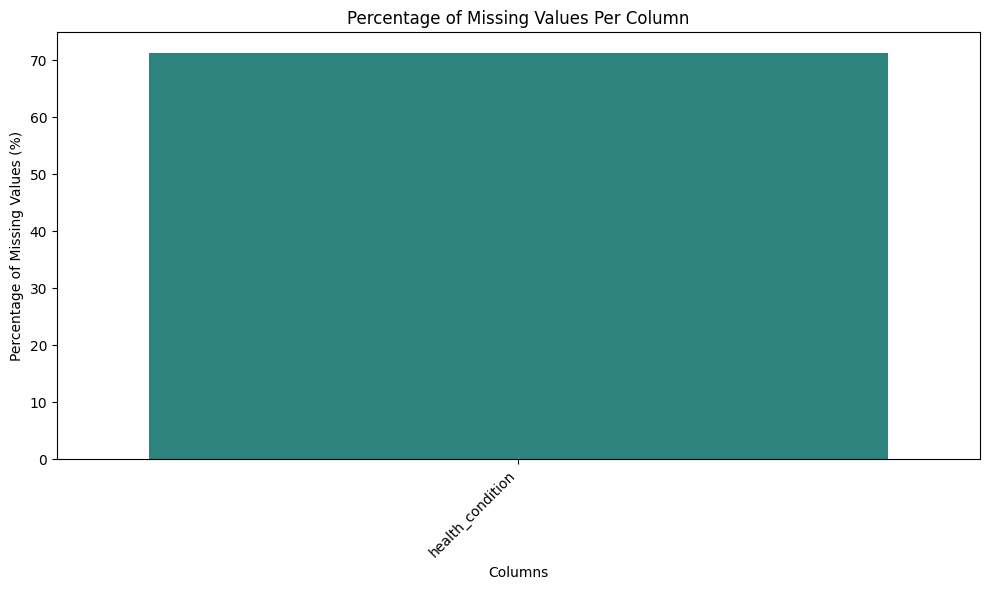

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


missing_percentage = df.isnull().sum() * 100 / len(df)

missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

if not missing_percentage.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_percentage.index, y=missing_percentage.values, hue=missing_percentage.index, palette='viridis', legend=False)
    plt.title('Percentage of Missing Values Per Column')
    plt.xlabel('Columns')
    plt.ylabel('Percentage of Missing Values (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

- Missing values 70% for health condition ... drop the columns

In [ ]:
df = df.drop('health_condition', axis=1)
print("DataFrame shape after dropping 'health_condition':", df.shape)
df.head()

DataFrame shape after dropping 'health_condition': (687701, 21)


,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,6.6,3,7128,1.5,19.6,69.5,110.7,72.9,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,8.1,7,7925,1.8,19.6,69.5,110.7,72.9,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,6.2,7,7557,2.7,19.6,69.5,110.7,72.9,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,7.2,8,11120,2.6,19.6,69.5,110.7,72.9,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,7.1,1,5406,1.5,19.6,69.5,110.7,72.9,Never,0.33


In [ ]:
df.tail()

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,smoking_status,fitness_level
687696,3000,2024-12-19,38,F,165.7,112.9,Basketball,44,Medium,13.2,...,7.4,6,6911,1.9,20.7,66.5,127.0,75.5,Never,17.13
687697,3000,2024-12-20,38,F,165.7,113.1,Basketball,25,Low,6.3,...,8.5,6,8932,2.6,20.7,66.5,127.0,75.5,Never,17.16
687698,3000,2024-12-21,38,F,165.7,113.4,Yoga,97,Low,9.1,...,8.2,8,8864,1.8,20.7,66.5,127.0,75.5,Never,17.26
687699,3000,2024-12-22,38,F,165.7,113.6,Basketball,108,Medium,32.6,...,8.5,4,7455,2.1,20.7,66.5,127.0,75.5,Never,17.39
687700,3000,2024-12-23,38,F,165.7,113.9,Yoga,29,High,3.8,...,7.4,2,9737,2.0,20.7,66.5,127.0,75.5,Never,17.43


In [ ]:
print("Column Information (Data Types and Non-Null Counts):")
df.info()

print("\nDescriptive Statistics for Numerical Columns:")
df.describe()

Column Information (Data Types and Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   participant_id            687701 non-null  int64  
 1   date                      687701 non-null  object 
 2   age                       687701 non-null  int64  
 3   gender                    687701 non-null  object 
 4   height_cm                 687701 non-null  float64
 5   weight_kg                 687701 non-null  float64
 6   activity_type             687701 non-null  object 
 7   duration_minutes          687701 non-null  int64  
 8   intensity                 687701 non-null  object 
 9   calories_burned           687701 non-null  float64
 10  avg_heart_rate            687701 non-null  int64  
 11  hours_sleep               687701 non-null  float64
 12  stress_level              687701 non-null  int6

,participant_id,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
count,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000
mean,1499.781828,41.658602,168.587699,94.921981,70.011671,15.381302,131.454165,7.048799,5.252389,8628.370918,2.499427,22.733134,70.010547,120.001260,80.188079,9.524900
std,865.997215,13.581770,9.140811,22.461801,29.147251,9.985552,17.814744,0.972068,2.770029,2054.756608,0.579050,3.568383,5.074563,10.008917,8.239418,5.502485
min,1.000000,18.000000,145.000000,45.300000,20.000000,0.800000,82.000000,4.000000,1.000000,-419.000000,1.500000,14.200000,51.100000,78.000000,53.700000,0.020000
25%,749.000000,30.000000,161.700000,78.200000,45.000000,7.800000,118.000000,6.400000,3.000000,7203.000000,2.000000,20.100000,66.500000,113.100000,74.600000,4.770000
50%,1499.000000,42.000000,168.200000,94.600000,70.000000,13.000000,130.000000,7.000000,5.000000,8607.000000,2.500000,22.400000,70.000000,120.200000,80.100000,9.510000
75%,2249.000000,53.000000,175.300000,110.500000,95.000000,20.700000,144.000000,7.700000,8.000000,10027.000000,3.000000,25.100000,73.500000,127.000000,85.700000,14.230000
max,3000.000000,64.000000,198.500000,188.400000,120.000000,92.000000,206.000000,10.000000,10.000000,17241.000000,3.500000,38.800000,87.100000,152.700000,112.100000,21.930000


In [ ]:
df['participant_id'].nunique()

3000

In [ ]:
print(df['participant_id'].unique())

[   1    2    3 ... 2998 2999 3000]


In [ ]:
print(df['age'])

0         56
1         56
2         56
3         56
4         56
          ..
687696    38
687697    38
687698    38
687699    38
687700    38
Name: age, Length: 687701, dtype: int64


In [ ]:
min_age = df['age'].min()
max_age = df['age'].max()
print(f"Minimum age: {min_age}")
print(f"Maximum age: {max_age}")

Minimum age: 18
Maximum age: 64


In [ ]:
df_young = df[
    (df['age'] >= 18) &
    (df['age'] <= 30) &
    (df['activity_type'].isin(['Swimming', 'Weight Training', 'Running']))
].copy()

print(df_young.shape)
df_young.head()

(52557, 21)


,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,smoking_status,fitness_level
482,3,2024-01-09,23,F,158.4,66.7,Weight Training,28,High,4.3,...,8.1,10,8954,3.4,25.7,68.0,118.4,69.0,Never,0.54
485,3,2024-01-16,23,F,158.4,67.5,Weight Training,95,Low,10.6,...,4.0,6,8601,3.2,25.7,68.0,118.4,69.0,Never,0.79
486,3,2024-01-18,23,F,158.4,67.7,Swimming,68,Medium,10.7,...,6.9,2,8051,2.9,25.7,68.0,118.4,69.0,Never,0.87
488,3,2024-01-20,23,F,158.4,68.2,Weight Training,81,High,12.8,...,6.6,10,11834,2.6,25.7,68.0,118.4,69.0,Never,1.02
490,3,2024-01-22,23,F,158.4,68.8,Weight Training,99,Medium,13.6,...,8.2,10,8393,2.0,25.7,68.0,118.4,69.0,Never,1.28


- Subset with people btw 18-30 that Swim, weight train or/and run

In [ ]:
df_young['participant_id'].nunique()

766

In [ ]:
df_young.shape

(52557, 21)

In [ ]:
df_young.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52557 entries, 482 to 687209
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            52557 non-null  int64  
 1   date                      52557 non-null  object 
 2   age                       52557 non-null  int64  
 3   gender                    52557 non-null  object 
 4   height_cm                 52557 non-null  float64
 5   weight_kg                 52557 non-null  float64
 6   activity_type             52557 non-null  object 
 7   duration_minutes          52557 non-null  int64  
 8   intensity                 52557 non-null  object 
 9   calories_burned           52557 non-null  float64
 10  avg_heart_rate            52557 non-null  int64  
 11  hours_sleep               52557 non-null  float64
 12  stress_level              52557 non-null  int64  
 13  daily_steps               52557 non-null  int64  
 14  hydratio

In [ ]:
# Hot encode activity types

In [ ]:
print(df_young['intensity'].unique())

['High' 'Low' 'Medium']


In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['participant_id', 'age', 'height_cm', 'weight_kg', 'duration_minutes', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fitness_level']
Categorical Columns: ['date', 'gender', 'activity_type', 'intensity', 'smoking_status']


In [ ]:
df_young['date'] = pd.to_datetime(df_young['date'])

print(df_young.dtypes)

participant_id                       int64
date                        datetime64[ns]
age                                  int64
gender                              object
height_cm                          float64
weight_kg                          float64
activity_type                       object
duration_minutes                     int64
intensity                           object
calories_burned                    float64
avg_heart_rate                       int64
hours_sleep                        float64
stress_level                         int64
daily_steps                          int64
hydration_level                    float64
bmi                                float64
resting_heart_rate                 float64
blood_pressure_systolic            float64
blood_pressure_diastolic           float64
smoking_status                      object
fitness_level                      float64
dtype: object


Before any analysis, the dataset was reviewed for completeness and
consistency. Out of 22 columns, only one had a significant missing
value issue: the health condition column, which was missing for
roughly 70% of participants. Since the column was mostly empty, it was removed from the dataset entirely.

A few columns also needed formatting adjustments before the analysis
could proceed. Dates were stored as plain text and were converted into
a proper date format to allow time-based analysis. Intensity levels,
originally recorded as Low, Medium, and High,  were converted to
numerical values to reflect their natural order and make them usable
in the model.

All other columns covering demographics, workout metrics, lifestyle
indicators, and health vitals were already in the right format and
required no changes.


# Exploratory Data Analysis (EDA)

In [ ]:
print("Descriptive Statistics for Numerical Columns:")
df_young.describe()

Descriptive Statistics for Numerical Columns:


,participant_id,date,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
count,52557.000000,52557,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000,52557.000000
mean,1535.510836,2024-06-16 10:34:31.762087168,23.814335,168.503166,94.009905,70.062028,16.274896,144.728999,7.046251,5.239435,8635.614932,2.498976,22.446616,70.154113,119.931893,80.352073,9.494854
min,3.000000,2024-01-01 00:00:00,18.000000,145.000000,45.300000,20.000000,1.800000,107.000000,4.000000,1.000000,994.000000,1.500000,14.200000,55.900000,84.700000,53.800000,0.020000
25%,786.000000,2024-03-21 00:00:00,21.000000,161.600000,77.200000,45.000000,9.300000,131.000000,6.400000,3.000000,7220.000000,2.000000,19.900000,66.500000,112.900000,74.700000,4.810000
50%,1531.000000,2024-06-06 00:00:00,24.000000,168.100000,93.400000,70.000000,14.600000,144.000000,7.000000,5.000000,8610.000000,2.500000,22.100000,70.000000,120.400000,79.900000,9.460000
75%,2301.000000,2024-09-10 00:00:00,27.000000,175.300000,109.400000,95.000000,21.500000,155.000000,7.700000,8.000000,10025.000000,3.000000,24.900000,73.600000,126.900000,85.500000,14.140000
max,2998.000000,2024-12-25 00:00:00,30.000000,198.500000,172.200000,120.000000,71.500000,202.000000,10.000000,10.000000,16500.000000,3.500000,34.300000,85.600000,151.800000,104.700000,21.470000
std,872.547877,NaN,3.743072,9.496855,22.771032,29.148953,9.127101,15.980555,0.975004,2.763205,2049.273987,0.578720,3.501231,5.014497,9.944589,7.904266,5.487108


In [ ]:
print("Descriptive Statistics for Categorical Columns:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_young[col].value_counts())


Descriptive Statistics for Categorical Columns:

--- date ---
date
2024-04-20    201
2024-04-22    199
2024-03-20    196
2024-04-24    194
2024-04-17    193
             ... 
2024-10-31    103
2024-10-23    102
2024-10-03    101
2024-08-31    100
2024-09-15     97
Name: count, Length: 360, dtype: int64

--- gender ---
gender
M        26099
F        25338
Other     1120
Name: count, dtype: int64

--- activity_type ---
activity_type
Weight Training    18055
Swimming           17517
Running            16985
Name: count, dtype: int64

--- intensity ---
intensity
Medium    26266
Low       15756
High      10535
Name: count, dtype: int64

--- smoking_status ---
smoking_status
Never      32951
Former     12067
Current     7539
Name: count, dtype: int64


In [ ]:
print("Mode for each column:")
for col in df_young.columns:
    mode_val = df_young[col].mode().tolist()
    print(f"Column '{col}': {mode_val}")

Mode for each column:
Column 'participant_id': [1880, 2155]
Column 'date': [Timestamp('2024-04-20 00:00:00')]
Column 'age': [21]
Column 'gender': ['M']
Column 'height_cm': [170.9]
Column 'weight_kg': [94.6]
Column 'activity_type': ['Weight Training']
Column 'duration_minutes': [53]
Column 'intensity': ['Medium']
Column 'calories_burned': [8.7]
Column 'avg_heart_rate': [147]
Column 'hours_sleep': [7.0]
Column 'stress_level': [5]
Column 'daily_steps': [9500]
Column 'hydration_level': [2.7]
Column 'bmi': [21.4]
Column 'resting_heart_rate': [73.3]
Column 'blood_pressure_systolic': [122.6]
Column 'blood_pressure_diastolic': [82.9]
Column 'smoking_status': ['Never']
Column 'fitness_level': [9.62]


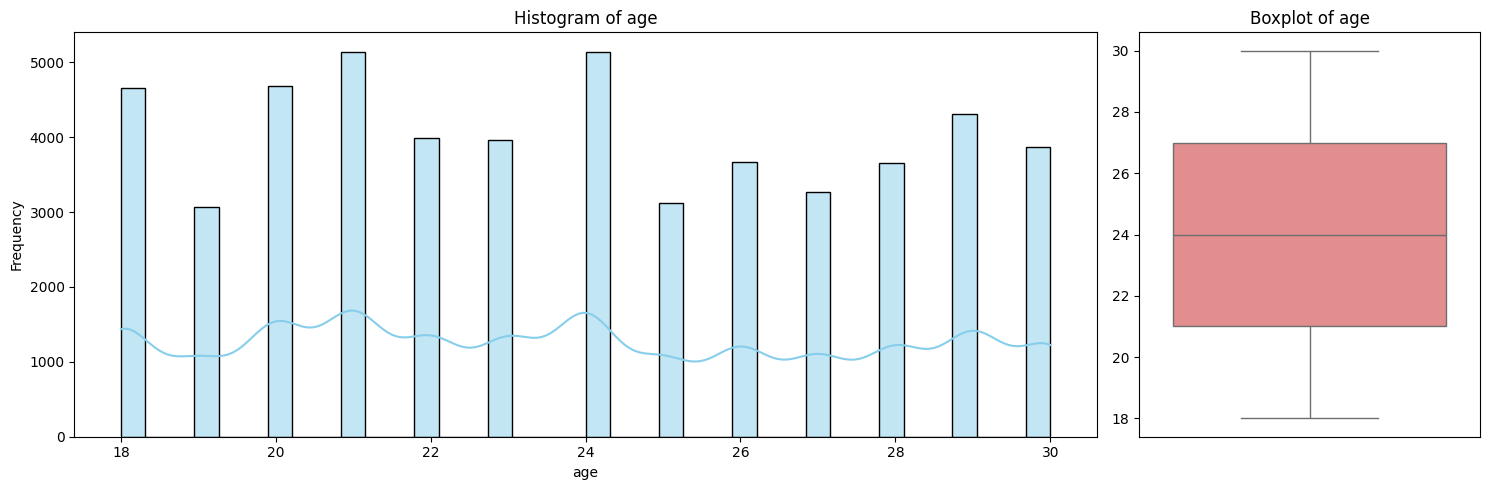

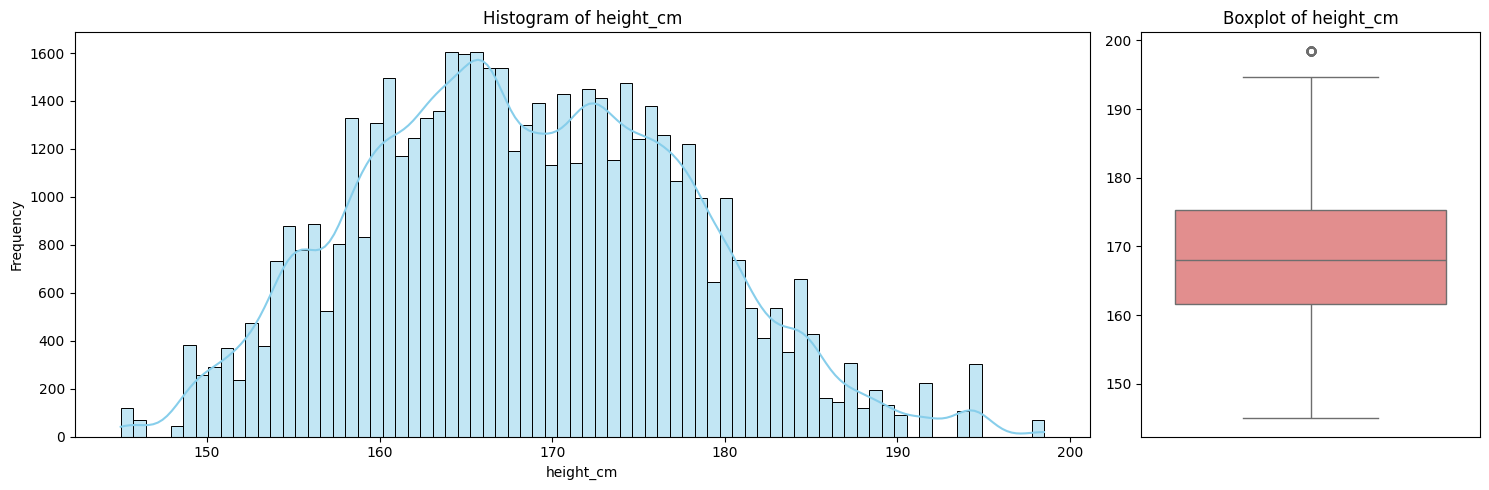

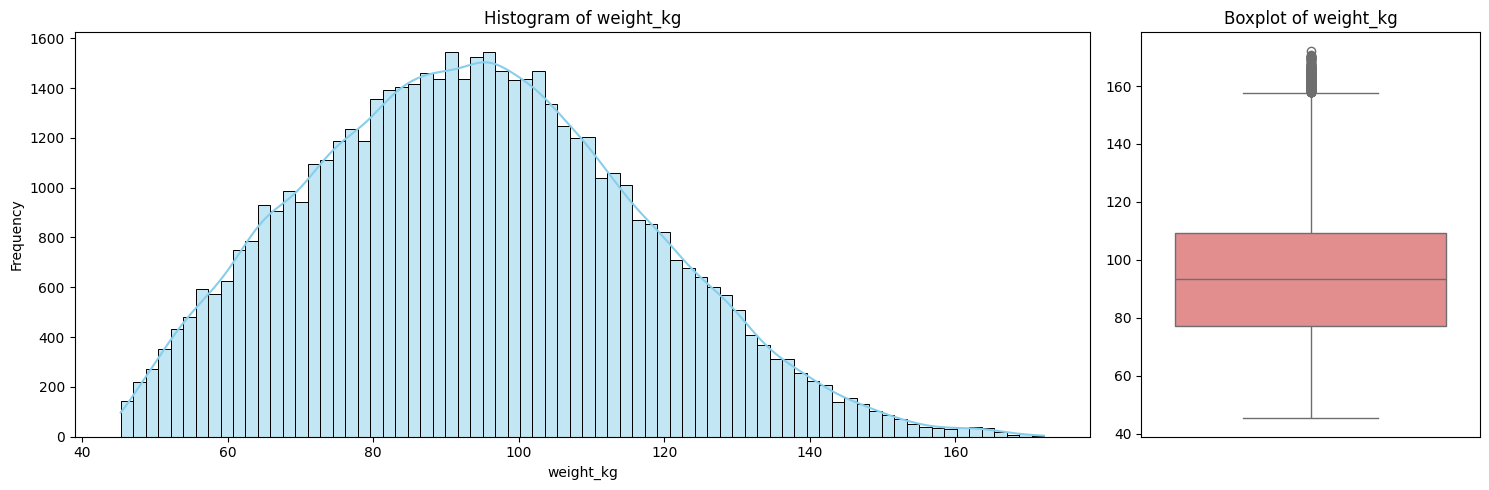

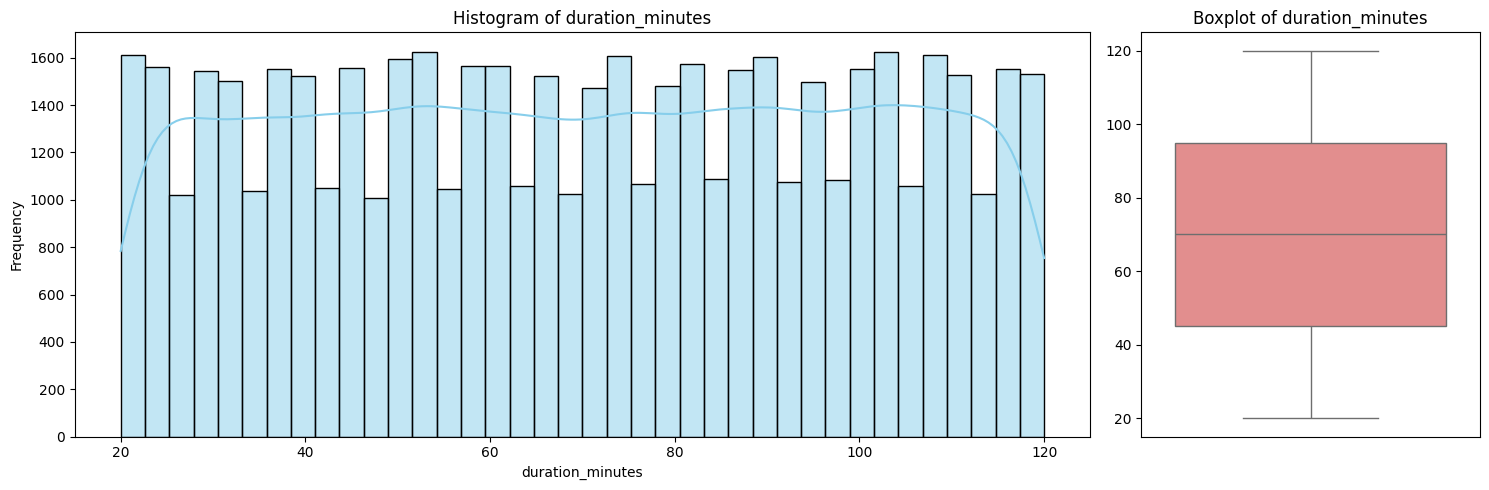

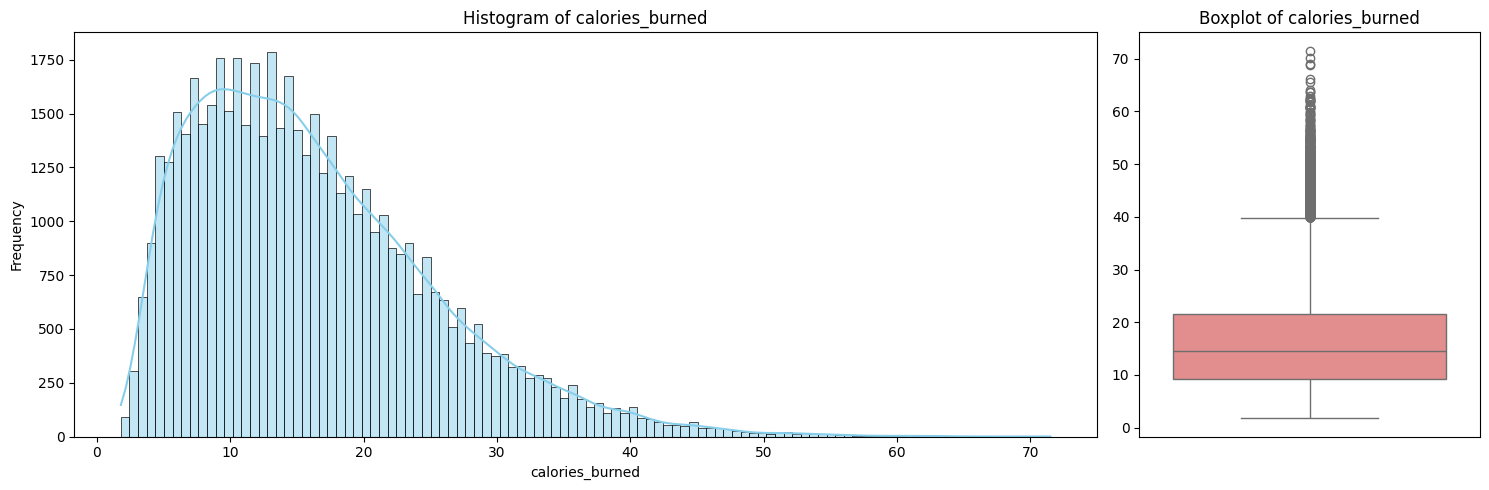

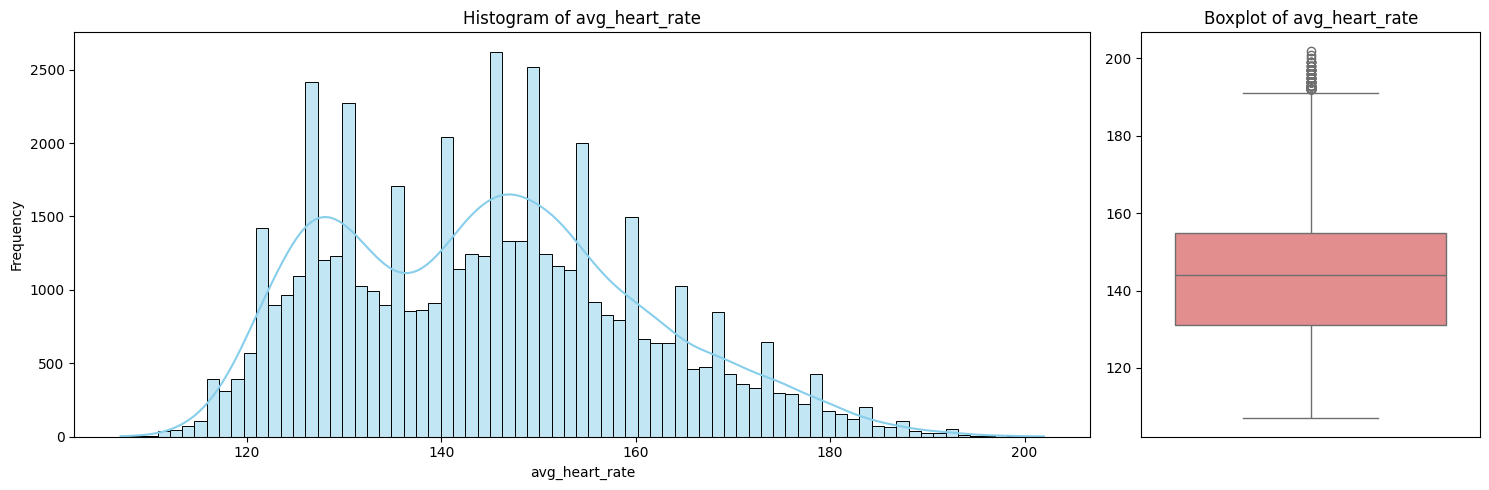

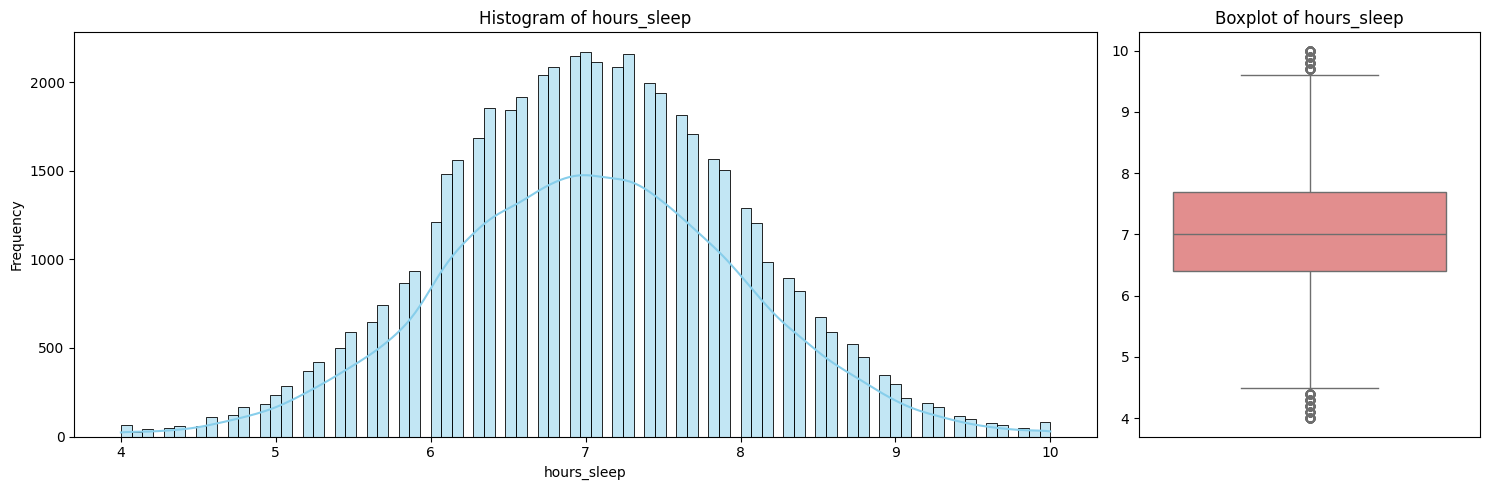

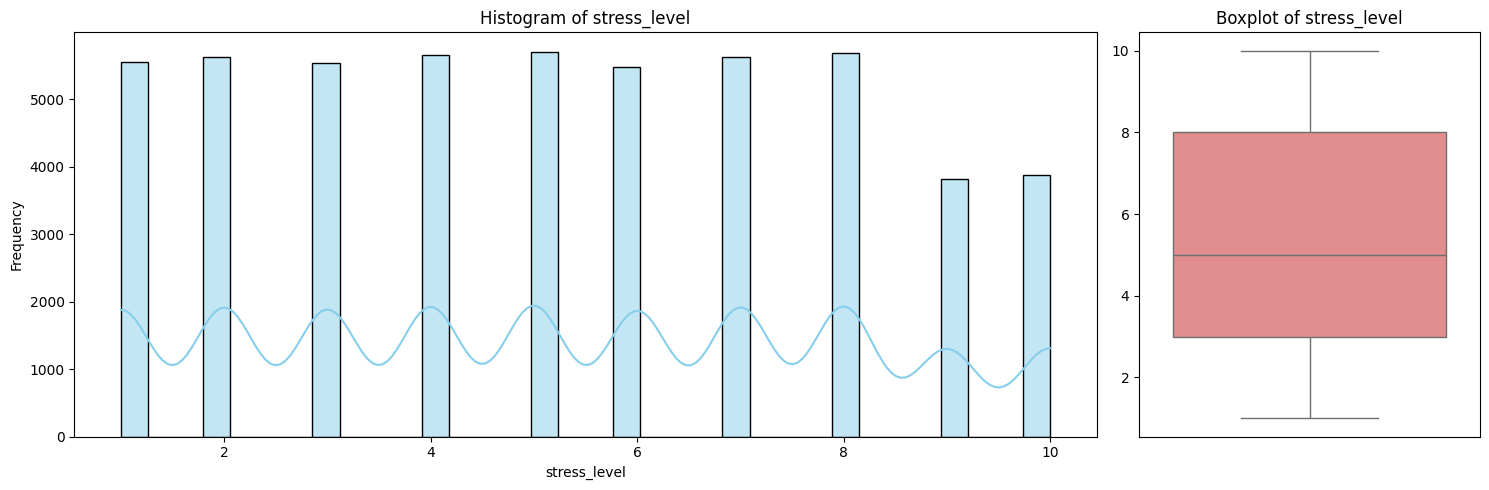

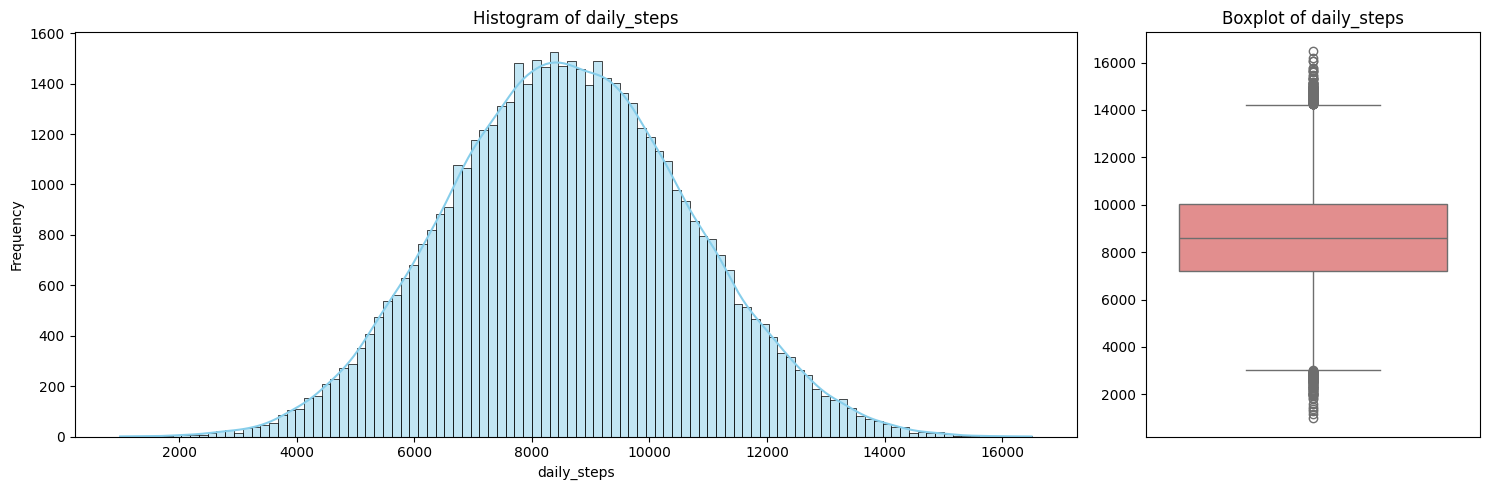

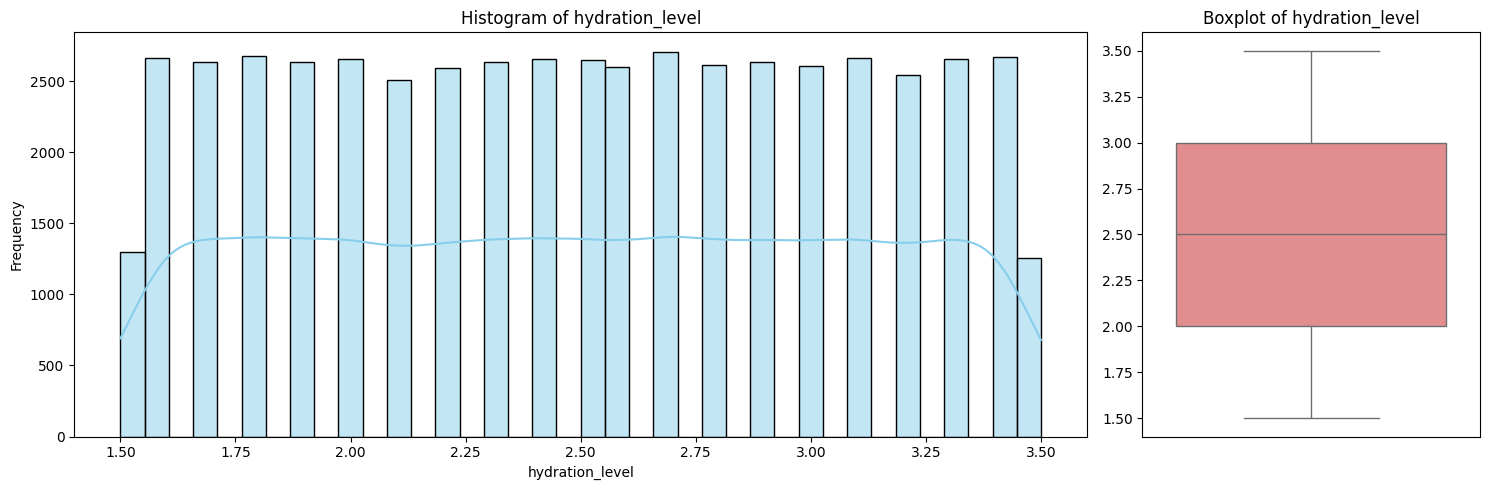

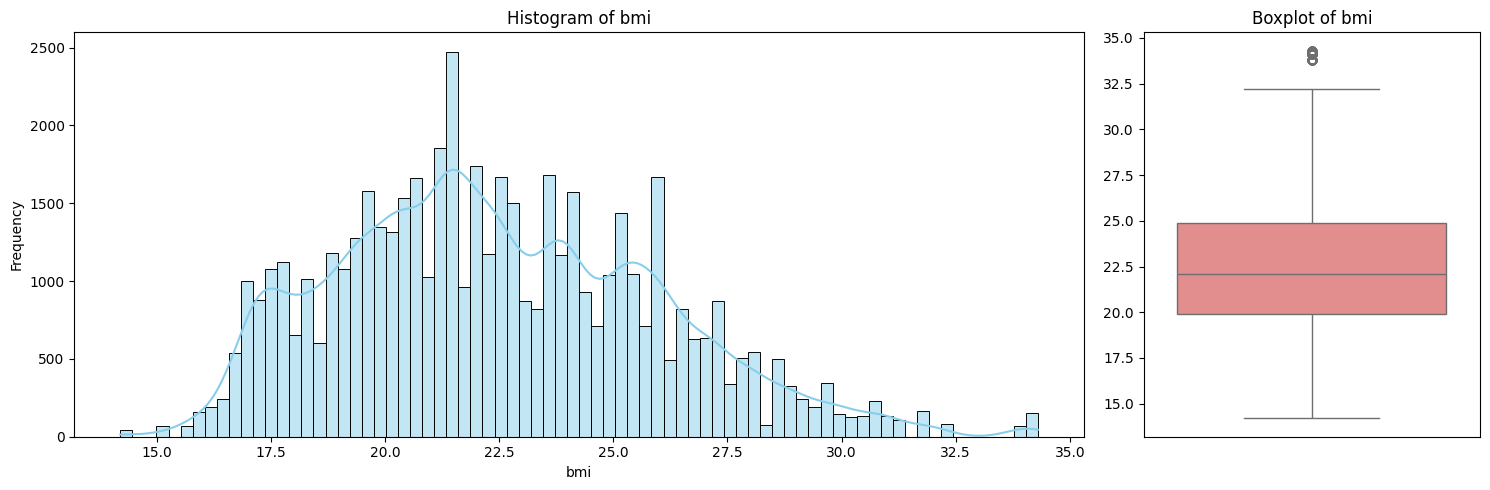

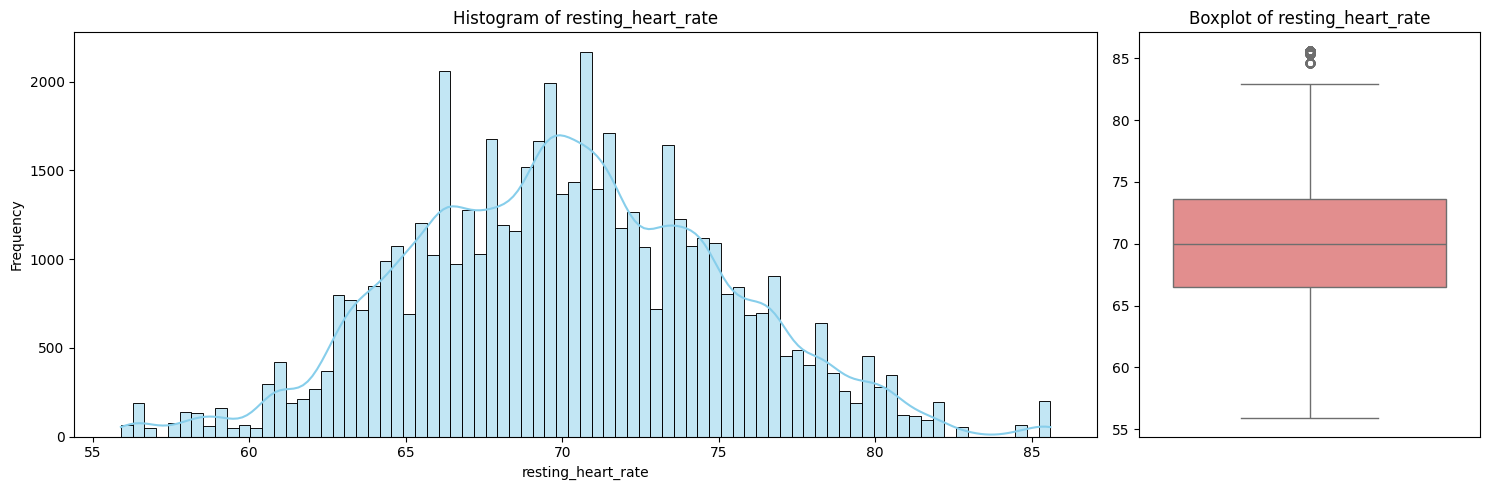

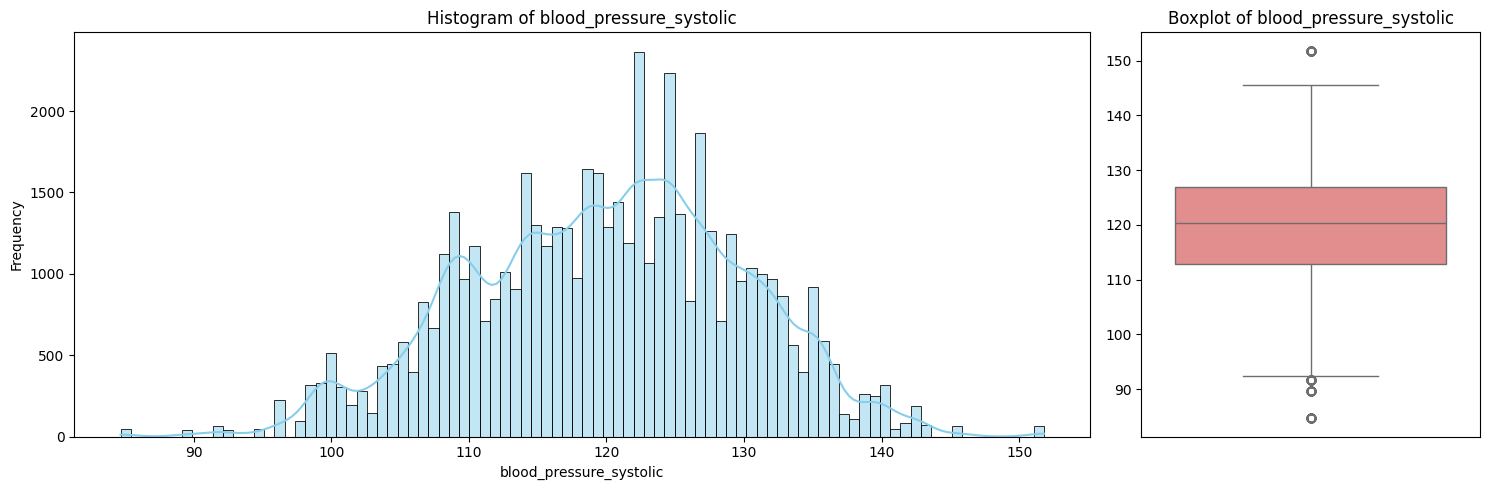

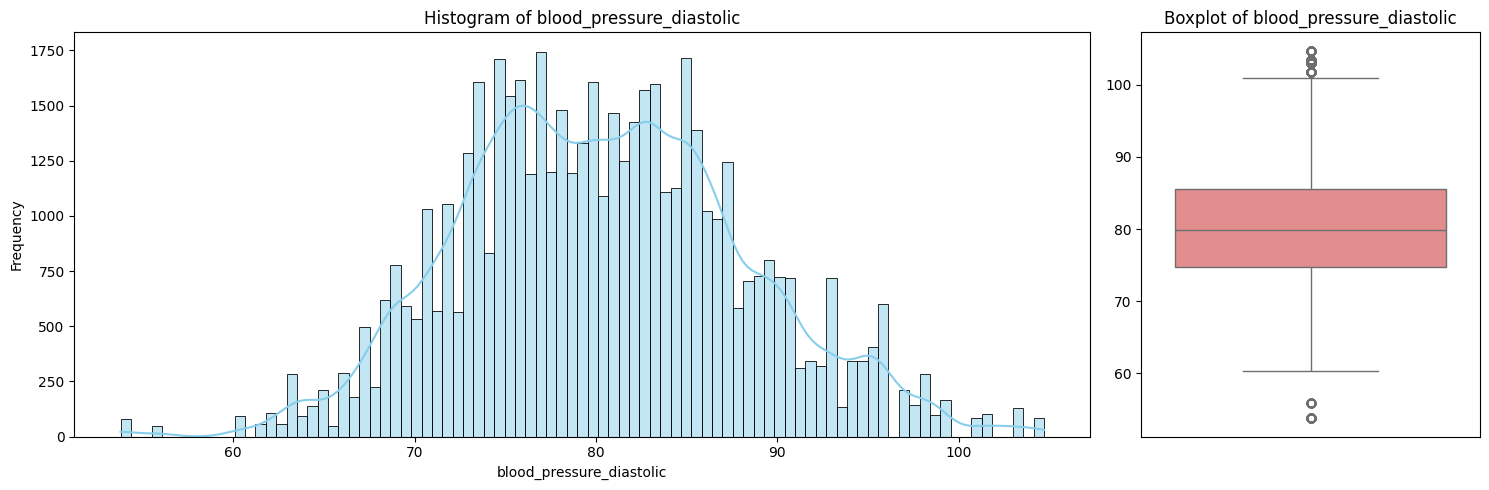

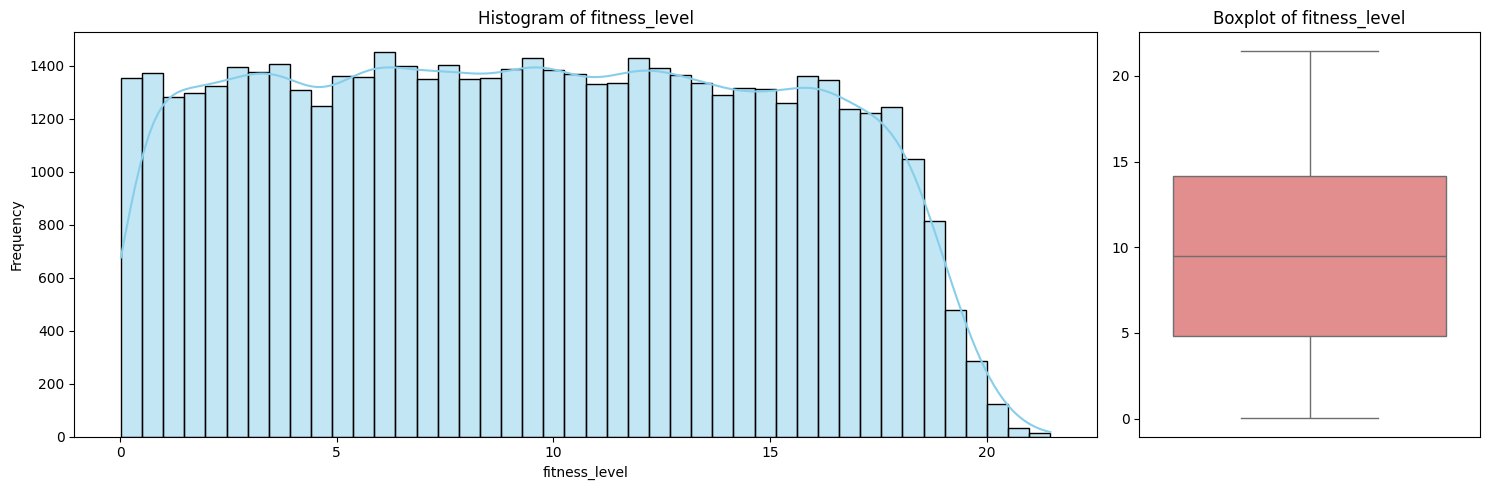

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns in df_young
numerical_cols_df_young = df_young.select_dtypes(include=['number']).columns.tolist()

# Plot histogram and boxplot for each numerical column
for col in numerical_cols_df_young:
    if col != 'participant_id': # participant_id is an identifier, not a measurement
        fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [3, 1]})

        # Histogram
        sns.histplot(df_young[col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'Histogram of {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')

        # Boxplot
        sns.boxplot(y=df_young[col], ax=axes[1], color='lightcoral')
        axes[1].set_title(f'Boxplot of {col}')
        axes[1].set_ylabel('') # Remove y-label for boxplot as it's redundant
        axes[1].set_xticks([]) # Remove x-axis ticks for boxplot

        plt.tight_layout()
        plt.show()

Descriptive statistics were calculated
for both numerical and categorical columns to get a sense of the
range, distribution, and typical values across the dataset.

* The average age in
the subset is 24, which aligns with the 18 to 30 focus.
* Weight ranges
widely from 45kg to 172kg reflecting genuine variation in body
composition across participants.
* Fitness level is fairly spread out,
suggesting the subset captures people at different stages of their
fitness journey rather than a uniform group.

On the categorical side, the three activities are reasonably balanced
*  Weight Training leads slightly with 18,055 sessions, followed by
Swimming at 17,517 and Running at 16,985.
* Intensity is skewed toward
Medium, which is the most common level across sessions. Most
participants have never smoked, and gender is fairly split between
male and female with a small Other category.

Histograms and boxplots were generated for every numerical column to
visualize the distributions.
*  Most health indicators, resting heart
rate, blood pressure, and sleep follow roughly normal distributions
with no extreme outliers.
*  Stress level appears more uniform,
suggesting it is evenly spread across the population.
*  Calories burned are right-skewed,
meaning most sessions burn a moderate amount with a smaller number
of high-output sessions pulling the distribution upward.

Overall, the data has no extreme outliers that would
distort the analysis, and a reasonable spread across all key variables.

# Feature Engineering

## Interaction terms

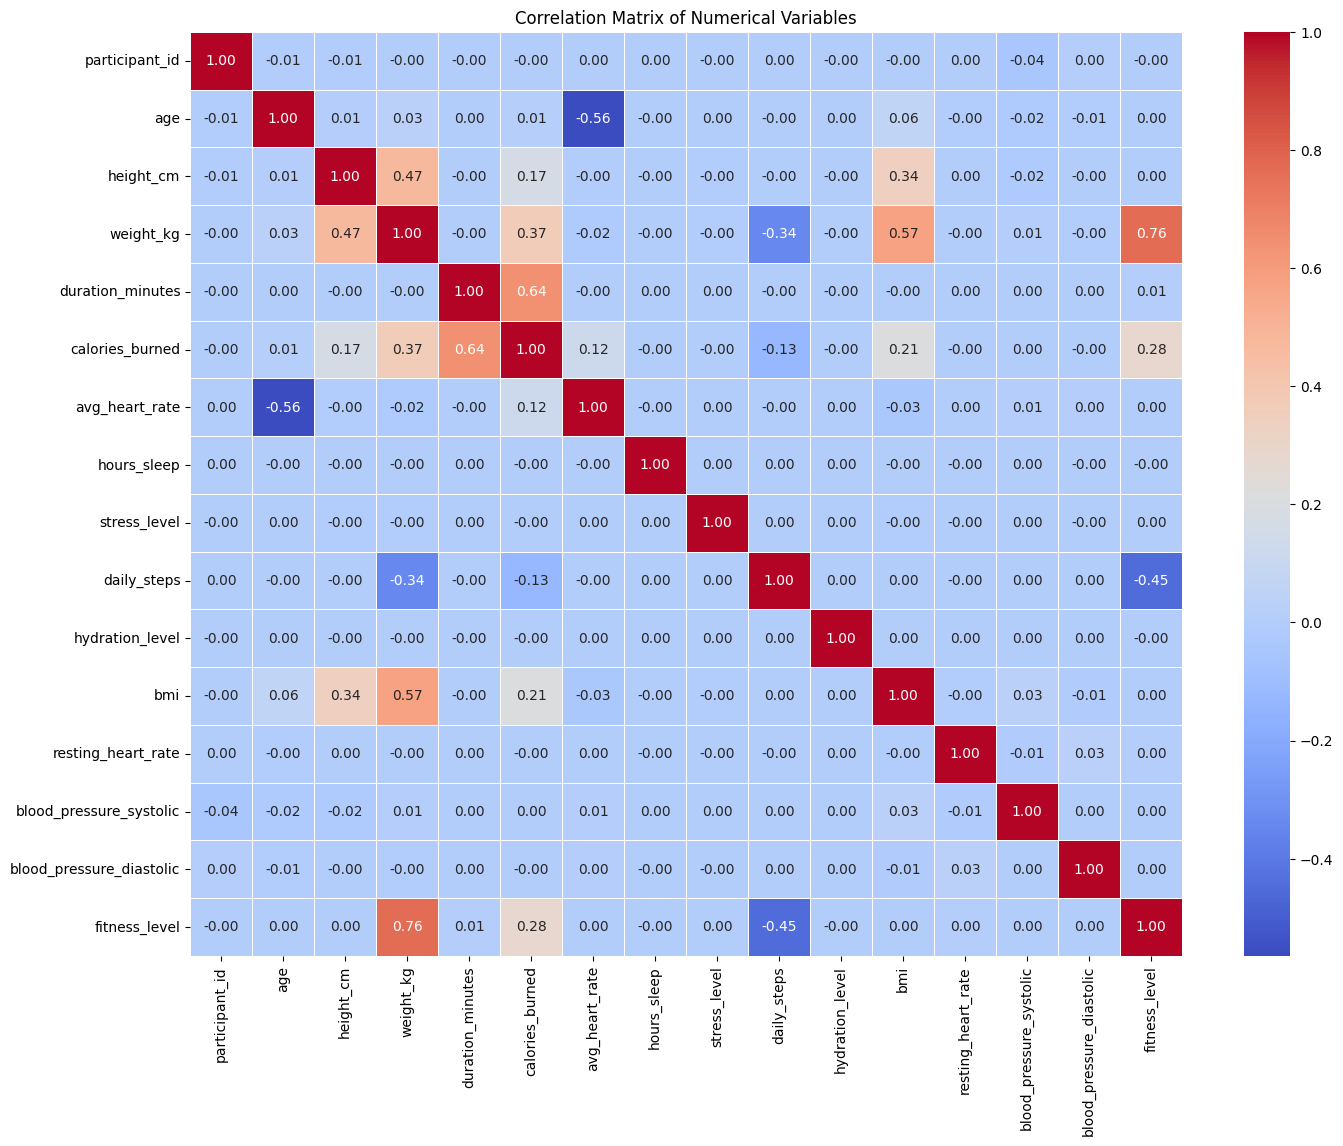

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns from the original DataFrame df
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [ ]:
import numpy as np

# Get the correlation matrix from the kernel state (assuming 'corr_matrix' is available)
# If 'corr_matrix' is not available, uncomment and run the previous cell that generates it.
# numerical_df = df.select_dtypes(include=['number'])
# corr_matrix = numerical_df.corr()

# Flatten the correlation matrix and remove self-correlations
correlations = corr_matrix.stack()

# Filter out self-correlations and duplicate pairs
# Keep only one side of the symmetric matrix (e.g., A-B but not B-A)
filtered_correlations = correlations[correlations.index.get_level_values(0) != correlations.index.get_level_values(1)]
filtered_correlations = filtered_correlations.loc[~filtered_correlations.index.duplicated(keep='first')]

# Sort the correlations
sorted_correlations = filtered_correlations.sort_values(ascending=False)

print("Top 5 positive correlations:")
print(sorted_correlations.head(5))

print("\nTop 5 negative correlations:")
print(sorted_correlations.tail(5))

Top 5 positive correlations:
weight_kg         fitness_level       0.761940
fitness_level     weight_kg           0.761940
calories_burned   duration_minutes    0.641077
duration_minutes  calories_burned     0.641077
bmi               weight_kg           0.573853
dtype: float64

Top 5 negative correlations:
daily_steps     weight_kg        -0.343977
                fitness_level    -0.449572
fitness_level   daily_steps      -0.449572
avg_heart_rate  age              -0.564767
age             avg_heart_rate   -0.564767
dtype: float64


In [ ]:
df_model = df_young.copy()

df_model['weight_fitness'] = df_model['weight_kg'] * df_model['fitness_level']
df_model['calories_duration'] = df_model['calories_burned'] * df_model['duration_minutes']
df_model['bmi_weight'] = df_model['bmi'] * df_model['weight_kg']

print(df_model.shape)
df_model.head()

(52557, 24)


,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,smoking_status,fitness_level,weight_fitness,calories_duration,bmi_weight
482,3,2024-01-09,23,F,158.4,66.7,Weight Training,28,High,4.3,...,3.4,25.7,68.0,118.4,69.0,Never,0.54,36.018,120.4,1714.19
485,3,2024-01-16,23,F,158.4,67.5,Weight Training,95,Low,10.6,...,3.2,25.7,68.0,118.4,69.0,Never,0.79,53.325,1007.0,1734.75
486,3,2024-01-18,23,F,158.4,67.7,Swimming,68,Medium,10.7,...,2.9,25.7,68.0,118.4,69.0,Never,0.87,58.899,727.6,1739.89
488,3,2024-01-20,23,F,158.4,68.2,Weight Training,81,High,12.8,...,2.6,25.7,68.0,118.4,69.0,Never,1.02,69.564,1036.8,1752.74
490,3,2024-01-22,23,F,158.4,68.8,Weight Training,99,Medium,13.6,...,2.0,25.7,68.0,118.4,69.0,Never,1.28,88.064,1346.4,1768.16


In [ ]:
df_model.head()

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,smoking_status,fitness_level,weight_fitness,calories_duration,bmi_weight
482,3,2024-01-09,23,F,158.4,66.7,Weight Training,28,High,4.3,...,3.4,25.7,68.0,118.4,69.0,Never,0.54,36.018,120.4,1714.19
485,3,2024-01-16,23,F,158.4,67.5,Weight Training,95,Low,10.6,...,3.2,25.7,68.0,118.4,69.0,Never,0.79,53.325,1007.0,1734.75
486,3,2024-01-18,23,F,158.4,67.7,Swimming,68,Medium,10.7,...,2.9,25.7,68.0,118.4,69.0,Never,0.87,58.899,727.6,1739.89
488,3,2024-01-20,23,F,158.4,68.2,Weight Training,81,High,12.8,...,2.6,25.7,68.0,118.4,69.0,Never,1.02,69.564,1036.8,1752.74
490,3,2024-01-22,23,F,158.4,68.8,Weight Training,99,Medium,13.6,...,2.0,25.7,68.0,118.4,69.0,Never,1.28,88.064,1346.4,1768.16


In [ ]:
df_model[['weight_fitness', 'calories_duration', 'bmi_weight']].describe()

,weight_fitness,calories_duration,bmi_weight
count,52557.000000,52557.000000,52557.000000
mean,988.193322,1337.379618,2156.677624
std,710.885855,1120.381324,783.206167
min,1.380000,36.000000,715.740000
25%,369.250000,431.200000,1577.180000
50%,869.526000,1046.500000,2033.520000
75%,1525.188000,1966.200000,2606.340000
max,3437.280000,8142.000000,5831.000000


In [ ]:
df_model[['weight_fitness', 'calories_duration', 'bmi_weight',
          'weight_kg', 'fitness_level', 'calories_burned',
          'duration_minutes', 'bmi']].corr().round(2)

,weight_fitness,calories_duration,bmi_weight,weight_kg,fitness_level,calories_burned,duration_minutes,bmi
weight_fitness,1.00,0.25,0.67,0.87,0.96,0.37,-0.00,0.20
calories_duration,0.25,1.00,0.26,0.28,0.22,0.96,0.84,0.17
bmi_weight,0.67,0.26,1.00,0.93,0.51,0.39,-0.00,0.83
weight_kg,0.87,0.28,0.93,1.00,0.77,0.43,-0.01,0.58
fitness_level,0.96,0.22,0.51,0.77,1.00,0.33,0.00,0.02
calories_burned,0.37,0.96,0.39,0.43,0.33,1.00,0.74,0.25
duration_minutes,-0.00,0.84,-0.00,-0.01,0.00,0.74,1.00,0.00
bmi,0.20,0.17,0.83,0.58,0.02,0.25,0.00,1.00


- weight_fitness = weight_kg × fitness_level
- calories_duration = calories_burned × duration_minutes
- bmi_weight = bmi × weight_kg


- weight_fitness = weight_kg × fitness_level ( Fitness level has 0.96, so drop)
- calories_duration = calories_burned × duration_minutes (cal burned 0.96)
- bmi_weight = bmi × weight_kg (bmi is litch 1 and weigth is 93 ) so the interactions terms are useless

In [ ]:
df_model = df_model.drop(columns=['weight_fitness', 'bmi_weight', 'calories_duration'])
print(df_model.shape)

(52557, 21)


In [ ]:
# encode intensity first
df_model['intensity'] = df_model['intensity'].map({'Low': 0, 'Medium': 1, 'High': 2})

# create new interaction terms
df_model['stress_sleep'] = df_model['stress_level'] * df_model['hours_sleep']
df_model['effort_score'] = df_model['duration_minutes'] * df_model['intensity']
df_model['cardio_effort'] = df_model['calories_burned'] * df_model['avg_heart_rate']

# evaluate them
df_model[['stress_sleep', 'effort_score', 'cardio_effort',
          'stress_level', 'hours_sleep', 'duration_minutes',
          'intensity', 'calories_burned', 'avg_heart_rate']].corr().round(2)

,stress_sleep,effort_score,cardio_effort,stress_level,hours_sleep,duration_minutes,intensity,calories_burned,avg_heart_rate
stress_sleep,1.00,-0.01,-0.01,0.96,0.24,-0.01,-0.00,-0.01,-0.00
effort_score,-0.01,1.00,0.65,-0.01,-0.00,0.44,0.83,0.53,0.72
cardio_effort,-0.01,0.65,1.00,-0.01,-0.00,0.69,0.36,0.98,0.36
stress_level,0.96,-0.01,-0.01,1.00,-0.01,-0.01,-0.00,-0.01,-0.00
hours_sleep,0.24,-0.00,-0.00,-0.01,1.00,-0.00,-0.00,-0.00,-0.00
duration_minutes,-0.01,0.44,0.69,-0.01,-0.00,1.00,0.00,0.74,0.00
intensity,-0.00,0.83,0.36,-0.00,-0.00,0.00,1.00,0.21,0.86
calories_burned,-0.01,0.53,0.98,-0.01,-0.00,0.74,0.21,1.00,0.18
avg_heart_rate,-0.00,0.72,0.36,-0.00,-0.00,0.00,0.86,0.18,1.00


- Stress lv * h sleep = 0.96 for stress
- effort score and duration min = 0.44 for durantion min and 0.83 for intensity ... interesting
- calories effort= cal burned = 0.98 , heart rate : 0.36

In [ ]:
df_model = df_model.drop(columns=['stress_sleep', 'cardio_effort'])
print(df_model.shape)
print(df_model.columns.tolist())

(52557, 22)
['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'smoking_status', 'fitness_level', 'effort_score']


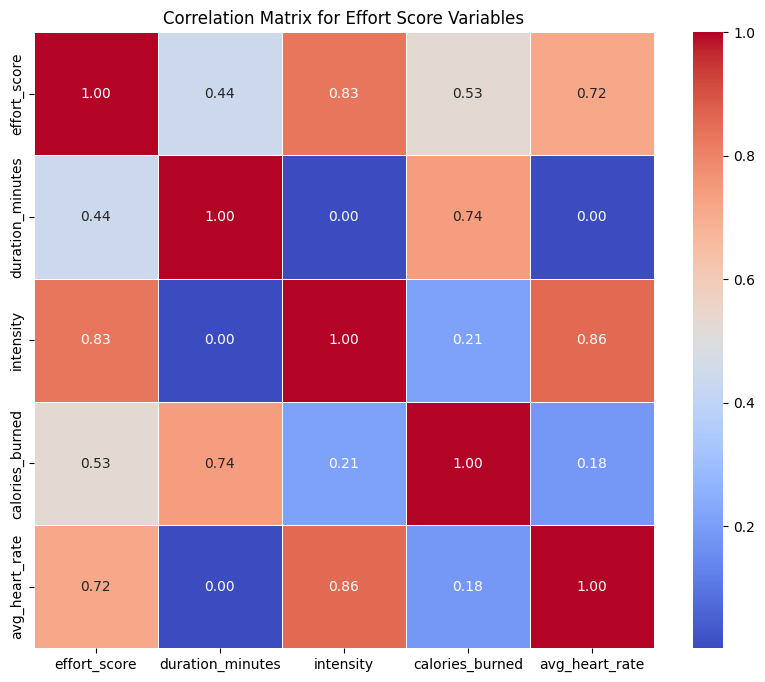

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for effort_score and related variables
corr_effort = df_model[['effort_score', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate']].corr()

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_effort, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix for Effort Score Variables')
plt.show()

In [ ]:
df_model['cal_duration'] = df_model['calories_burned'] * df_model['duration_minutes']

df_model[['cal_duration', 'calories_burned', 'duration_minutes']].corr().round(2)

,cal_duration,calories_burned,duration_minutes
cal_duration,1.00,0.96,0.84
calories_burned,0.96,1.00,0.74
duration_minutes,0.84,0.74,1.00


* Cal burned has a too corr

In [ ]:
df_model['heart_effort'] = df_model['avg_heart_rate'] * df_model['effort_score']

df_model[['heart_effort', 'avg_heart_rate', 'effort_score']].corr().round(2)

,heart_effort,avg_heart_rate,effort_score
heart_effort,1.00,0.75,0.99
avg_heart_rate,0.75,1.00,0.72
effort_score,0.99,0.72,1.00


* effort score is 0.99 so no

In [ ]:
df_model = df_model.drop(columns=['cal_duration', 'heart_effort'])
print(df_model.columns.tolist())

['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'smoking_status', 'fitness_level', 'effort_score']


In [ ]:
print("Kept interaction term: 'effort_score'")

Kept interaction term: 'effort_score'


The correlation matrix revealed several strong relationships between
variables.

Three combinations were tried first, based on the strongest
correlations in the data:
* weight × fitness level (0.76),
* calories burned × duration (0.64), and
* BMI × weight (0.57).

The reasoning
was that variables already moving together might produce a stronger
combined signal. That turned out to be the wrong approach; all
three correlated above 0.90 with at least one original variable
and were dropped.

A second test was used with more independent variables. The
rule applied was simple: if an interaction term correlates above
0.90 with any of its original variables, it is redundant and gets
dropped.

- Stress × sleep correlated 0.96 with stress level — dropped.
- Calories × heart rate correlated 0.98 with calories burned — dropped.
- Duration × intensity correlated 0.44 with duration and 0.83
  with intensity, both under the threshold — kept.

The one that was maintained was the effort score. A person training
90 minutes at high intensity is fundamentally different from someone
training 90 minutes at low intensity. Effort score captures that
difference in a single number, which neither variable could do alone.

* effort_score
(duration_minutes × intensity).

## Clustering

In [ ]:
print(df_model.columns.tolist())
print(df_model.shape)

['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'smoking_status', 'fitness_level', 'effort_score']
(52557, 22)


In [ ]:
# drop non-numerical and identifier columns
cluster_df = df_model.drop(columns=['participant_id', 'date', 'activity_type', 'gender', 'smoking_status', 'health_condition'], errors='ignore')

print(cluster_df.shape)
print(cluster_df.columns.tolist())

(52557, 17)
['age', 'height_cm', 'weight_kg', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fitness_level', 'effort_score']


### Timeline breakdown

In [ ]:
# extract from date column in df_young (still has date)
date_features = df_young.groupby('participant_id').agg(
    total_active_days=('date', 'nunique'),
    active_months=('date', lambda x: x.dt.month.nunique())
).reset_index()

print(date_features.shape)
date_features.head(10)

(766, 3)


,participant_id,total_active_days,active_months
0,3,45,12
1,7,67,11
2,9,66,10
3,12,73,11
4,17,53,12
5,25,50,9
6,26,78,12
7,28,45,11
8,34,65,10
9,35,68,12


In [ ]:
print(date_features['participant_id'].nunique())

766


In [ ]:
print(date_features[['total_active_days', 'active_months']].describe())

       total_active_days  active_months
count         766.000000     766.000000
mean           68.612272      10.608355
std            17.902271       1.216717
min            22.000000       6.000000
25%            56.000000      10.000000
50%            68.000000      11.000000
75%            81.000000      11.000000
max           132.000000      12.000000


In [ ]:
date_features = df_young.groupby('participant_id').agg(
    total_active_days=('date', 'nunique'),
    active_months=('date', lambda x: x.dt.month.nunique())
).reset_index()

# add longest streak
def longest_streak(dates):
    months = sorted(dates.dt.month.unique())
    max_streak = 1
    current = 1
    for i in range(1, len(months)):
        if months[i] == months[i-1] + 1:
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 1
    return max_streak

streak = df_young.groupby('participant_id')['date'].apply(longest_streak).reset_index()
streak.columns = ['participant_id', 'longest_streak']

date_features = date_features.merge(streak, on='participant_id')

print(date_features.shape)
date_features.head()

(766, 4)


,participant_id,total_active_days,active_months,longest_streak
0,3,45,12,12
1,7,67,11,7
2,9,66,10,10
3,12,73,11,9
4,17,53,12,12


- Merging all df ( infoin one )

In [ ]:
df_model2 = df_model.copy()
df_model2 = df_model2.merge(date_features, on='participant_id', how='left')

print(df_model2.shape)
print(df_model2.columns.tolist())

(52557, 25)
['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'smoking_status', 'fitness_level', 'effort_score', 'total_active_days', 'active_months', 'longest_streak']


In [ ]:
cluster_df = df_model2.drop(columns=['participant_id', 'date', 'activity_type', 'gender', 'smoking_status'])

print(cluster_df.shape)

(52557, 20)


The date column carried more information than just when a session
happened. By looking across all sessions per person, it was possible
to understand how often someone showed up and how consistently they
did so over the year.

Three features were extracted from this:
* the total number of unique
days a participant was active,
* the number of distinct months they
showed up, and
* the length of their longest consecutive streak of
active months.

These features were added to the dataset before
clustering, on the basis that consistency patterns could help define
more meaningful profiles, someone active across 11 months tells a
different story than someone who showed up intensely for 2 months
and stopped.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

print(cluster_scaled.shape)

(52557, 20)


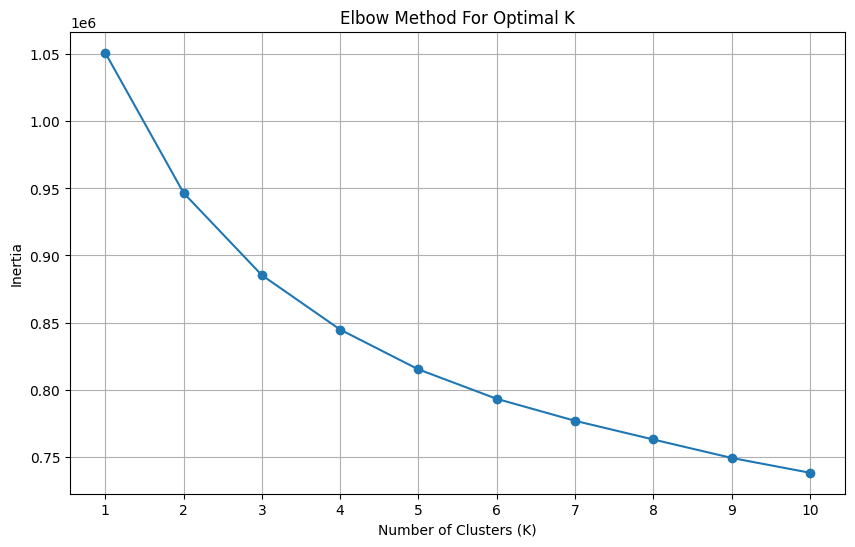

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
# Consider a reasonable range for K, e.g., from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# k=3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = kmeans3.fit_predict(cluster_scaled)
score3 = silhouette_score(cluster_scaled, labels3, sample_size=5000, random_state=42)

# k=4
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4 = kmeans4.fit_predict(cluster_scaled)
score4 = silhouette_score(cluster_scaled, labels4, sample_size=5000, random_state=42)

print(f"k=3 silhouette score: {score3:.4f}")
print(f"k=4 silhouette score: {score4:.4f}")

k=3 silhouette score: 0.0784
k=4 silhouette score: 0.0721


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# k=3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = kmeans3.fit_predict(cluster_scaled)
score3 = silhouette_score(cluster_scaled, labels3, sample_size=5000, random_state=42)

# k=4
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4 = kmeans4.fit_predict(cluster_scaled)
score4 = silhouette_score(cluster_scaled, labels4, sample_size=5000, random_state=42)

print(f"k=3 silhouette score: {score3:.4f}")
print(f"k=4 silhouette score: {score4:.4f}")

k=3 silhouette score: 0.0784
k=4 silhouette score: 0.0721


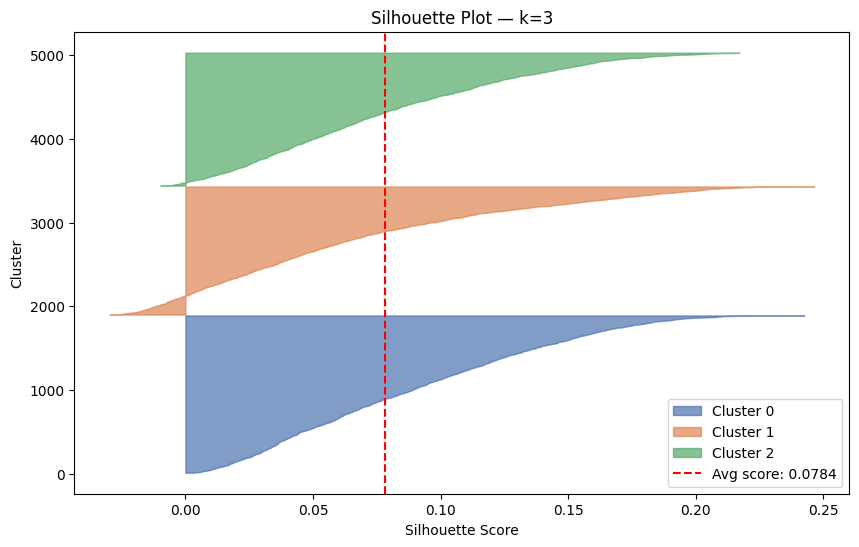

In [ ]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

sample_idx = np.random.choice(len(cluster_scaled), 5000, replace=False)
X_sample = cluster_scaled[sample_idx]
labels_sample = labels3[sample_idx]

silhouette_vals = silhouette_samples(X_sample, labels_sample)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors = ['#4C72B0', '#DD8452', '#55A868']

for i in range(3):
    cluster_vals = np.sort(silhouette_vals[labels_sample == i])
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     alpha=0.7, color=colors[i], label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=score3, color='red', linestyle='--', label=f'Avg score: {score3:.4f}')
ax.set_xlabel('Silhouette Score')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — k=3')
ax.legend()
plt.show()

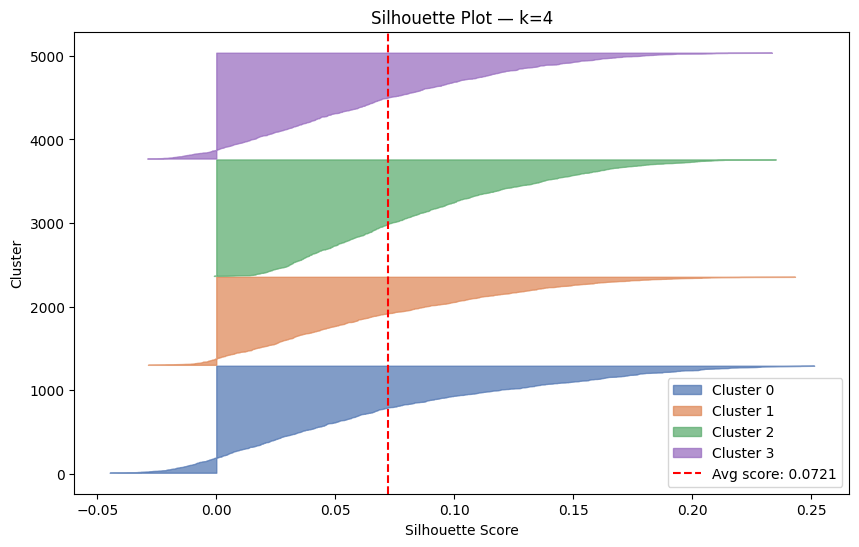

In [ ]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

sample_idx = np.random.choice(len(cluster_scaled), 5000, replace=False)
X_sample = cluster_scaled[sample_idx]
labels_sample = labels4[sample_idx]

silhouette_vals = silhouette_samples(X_sample, labels_sample)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors = ['#4C72B0', '#DD8452', '#55A868', '#9467BD']

for i in range(4):
    cluster_vals = np.sort(silhouette_vals[labels_sample == i])
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     alpha=0.7, color=colors[i], label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=score4, color='red', linestyle='--', label=f'Avg score: {score4:.4f}')
ax.set_xlabel('Silhouette Score')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — k=4')
ax.legend()
plt.show()

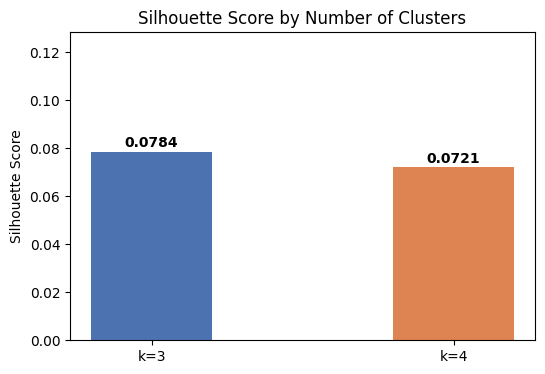

In [ ]:
import matplotlib.pyplot as plt

scores = [score3, score4]
labels = ['k=3', 'k=4']
colors = ['#4C72B0', '#DD8452']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, scores, color=colors, width=0.4)
plt.title('Silhouette Score by Number of Clusters')
plt.ylabel('Silhouette Score')
plt.ylim(0, max(scores) + 0.05)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{score:.4f}', ha='center', fontweight='bold')
plt.show()

In [ ]:
df_model2['cluster'] = labels3

cluster_profile = df_model2.groupby('cluster')[cluster_df.columns.tolist()].mean().round(2)
cluster_profile.T

cluster,0,1,2
age,23.91,23.59,23.92
height_cm,164.75,169.85,171.62
weight_kg,74.40,101.15,110.20
duration_minutes,61.39,89.30,61.64
intensity,0.80,1.50,0.44
calories_burned,10.52,24.58,15.02
avg_heart_rate,142.46,157.61,134.92
hours_sleep,7.04,7.05,7.05
stress_level,5.28,5.18,5.25
daily_steps,9619.96,8352.81,7749.08


In [ ]:
cluster_labels = {
    0: 'Moderate Active - Steps Focused',
    1: 'High-Intensity Training',
    2: 'Consistent Low-Intensity Fitness'
}

# Map the labels to the cluster profile
cluster_profile_labeled = cluster_profile.rename(index=cluster_labels)

print("Cluster Profiles with Labels:")
print(cluster_profile_labeled.T)

# You can also add the labels back to the main DataFrame if needed:
df_model2['cluster_label'] = df_model2['cluster'].map(cluster_labels)
print(df_model2[['cluster', 'cluster_label']].head())

Cluster Profiles with Labels:
cluster                   Moderate Active - Steps Focused  \
age                                                 23.91   
height_cm                                          164.75   
weight_kg                                           74.40   
duration_minutes                                    61.39   
intensity                                            0.80   
calories_burned                                     10.52   
avg_heart_rate                                     142.46   
hours_sleep                                          7.04   
stress_level                                         5.28   
daily_steps                                       9619.96   
hydration_level                                      2.50   
bmi                                                 21.00   
resting_heart_rate                                  70.17   
blood_pressure_systolic                            119.72   
blood_pressure_diastolic                            80.

In [ ]:
# Checking weight changes overtime

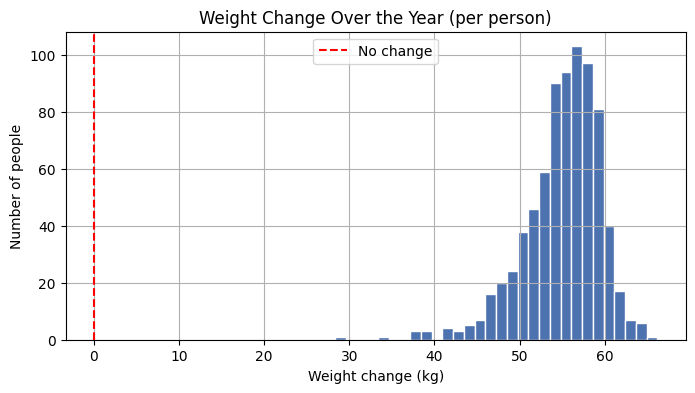

In [ ]:
df_young_sorted = df_young.sort_values(['participant_id', 'date'])

weight_change = df_young_sorted.groupby('participant_id').agg(
    first_weight=('weight_kg', 'first'),
    last_weight=('weight_kg', 'last')
).reset_index()

weight_change['weight_change'] = weight_change['last_weight'] - weight_change['first_weight']

weight_change['weight_change'].hist(bins=30, figsize=(8,4), color='#4C72B0', edgecolor='white')
plt.title('Weight Change Over the Year (per person)')
plt.xlabel('Weight change (kg)')
plt.ylabel('Number of people')
plt.axvline(x=0, color='red', linestyle='--', label='No change')
plt.legend()
plt.show()

* Weight change over time was explored out of curiosity to see
whether any patterns emerged across the year. The findings showed
that all participants gained weight over the course of the year
with no variation in the other direction. Given this uniform
pattern, no meaningful insight could be drawn from it and it
was not incorporated into the model.

**Clustering Summary**:   

K-Means was chosen over hierarchical clustering for
practical reasons: with 52,557 sessions in the dataset, hierarchical
clustering would be too slow. KMeans is faster and
well suited to this scale.

Before running the algorithm,
 * All numerical columns were scaled so
that no single variable, like daily steps ranging in the thousands,
would dominate over variables measured on a smaller scale like
hydration level.
*  Non-numerical columns such as participant ID, date,
activity type, gender, and smoking status were excluded, as the model
can only work with numbers.


**Choosing the number of clusters**

KMeans requires deciding upfront how many groups to look for.

The elbow method plots curve showed no sharp bend, the data did
not naturally point to one An obvious number of clusters.

K=3 and K=4 were compared directly using the silhouette
score.

 K=3 scored 0.0784 against k=4 at 0.0721. The
difference is small, but k=3 also produces more interpretable and
actionable profiles, K=3 was selected.

**The three profiles**

- Cluster 0:  Moderate Active, Steps Focused: Lightest group
  (74kg average), lowest fitness level, highest daily steps.
  They are active through movement rather than
  structured training.

- Cluster 1:  High Intensity Trainers: Heaviest effort score
  (128.92), longest sessions (89 minutes), most calories burned
  (24.58), highest heart rate (157 bpm). This group pushes hard
  when they show up.

- Cluster 2: Consistent Low Intensity: Heaviest group (110kg),
  highest fitness level (12.83), most active days (76), longest
  streak (9.51 months). They are most consistent but
  train at the lowest intensity.

NB:  Sleep, stress, and hydration were nearly
identical across all three clusters. This suggests that for young
adults aged 18 to 30, workout behavior and body composition drive
behavioral differences more than daily lifestyle habits.

# Modeling ( predicting Activity)

In [ ]:
print(df_model2['activity_type'].value_counts())
print(df_model2['activity_type'].dtype)

activity_type
Weight Training    18055
Swimming           17517
Running            16985
Name: count, dtype: int64
object


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model2['activity_encoded'] = le.fit_transform(df_model2['activity_type'])
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(df_model2['activity_encoded'].value_counts())

{'Running': np.int64(0), 'Swimming': np.int64(1), 'Weight Training': np.int64(2)}
activity_encoded
2    18055
1    17517
0    16985
Name: count, dtype: int64


In [ ]:
print(df_model2['cluster'].dtype)
print(df_model2['cluster'].value_counts())

int32
cluster
0    19684
2    16695
1    16178
Name: count, dtype: int64


In [ ]:
# activity encoding
print("Activity encoding:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# cluster labels
print("\nCluster distribution:")
print(df_model2['cluster'].value_counts())

# what each cluster means
cluster_names = {0: 'Casual Movers', 1: 'High Intensity Trainers', 2: 'Consistent Low Effort'}
print("\nCluster names:")
for k, v in cluster_names.items():
    print(f"Cluster {k} = {v}")


Activity encoding:
{'Running': np.int64(0), 'Swimming': np.int64(1), 'Weight Training': np.int64(2)}

Cluster distribution:
cluster
0    19684
2    16695
1    16178
Name: count, dtype: int64

Cluster names:
Cluster 0 = Casual Movers
Cluster 1 = High Intensity Trainers
Cluster 2 = Consistent Low Effort


In [ ]:
# Baseline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# define features and target
features = ['age', 'bmi', 'weight_kg', 'height_cm', 'duration_minutes',
            'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep',
            'stress_level', 'daily_steps', 'hydration_level', 'resting_heart_rate',
            'blood_pressure_systolic', 'blood_pressure_diastolic', 'fitness_level',
            'effort_score', 'total_active_days', 'active_months', 'longest_streak',
            'cluster']

X = df_model2[features]
y = df_model2['activity_encoded']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# baseline model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=['Running', 'Swimming', 'Weight Training']))

print(f"Baseline accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

                 precision    recall  f1-score   support

        Running       0.91      0.91      0.91      3432
       Swimming       0.75      0.72      0.74      3555
Weight Training       0.79      0.82      0.80      3525

       accuracy                           0.82     10512
      macro avg       0.82      0.82      0.82     10512
   weighted avg       0.82      0.82      0.82     10512

Baseline accuracy: 0.8155


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
lr = LogisticRegression(max_iter=2000, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=['Running', 'Swimming', 'Weight Training']))
print(f"Baseline accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

                 precision    recall  f1-score   support

        Running       0.92      0.93      0.93      3432
       Swimming       0.79      0.75      0.77      3555
Weight Training       0.81      0.84      0.82      3525

       accuracy                           0.84     10512
      macro avg       0.84      0.84      0.84     10512
   weighted avg       0.84      0.84      0.84     10512

Baseline accuracy: 0.8393


In [ ]:
# Other models

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Decision Tree
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_scaled, y_train)
y_pred_dtc = dtc.predict(X_test_scaled)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Compare all
print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Decision Tree:       {accuracy_score(y_test, y_pred_dtc):.4f}")
print(f"KNN:                 {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Random Forest:       {accuracy_score(y_test, y_pred_rf):.4f}")

Logistic Regression: 0.8393
Decision Tree:       0.9188
KNN:                 0.5035
Random Forest:       0.8993


In [ ]:
print(f"Train accuracy: {accuracy_score(y_train, dtc.predict(X_train_scaled)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_pred_dtc):.4f}")

Train accuracy: 1.0000
Test accuracy:  0.9188


In [ ]:
print(f"Train accuracy: {accuracy_score(y_train, rf.predict(X_train_scaled)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")

Train accuracy: 1.0000
Test accuracy:  0.8993


In [ ]:
# New baseline

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

activity_names = ['Running', 'Swimming', 'Weight Training']

models = {
    'Logistic Regression': lr,
    'Decision Tree': dtc,
    'KNN': knn,
    'Random Forest': rf
}

predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dtc,
    'KNN': y_pred_knn,
    'Random Forest': y_pred_rf
}

# baseline comparison with cross validation
print("="*55)
print(f"{'Model':<25} {'CV Mean':>10} {'Test Acc':>10}")
print("="*55)
for name, model in models.items():
    cv = cross_val_score(model, X_train_scaled, y_train, cv=5)
    test_acc = accuracy_score(y_test, predictions[name])
    print(f"{name:<25} {cv.mean():>10.4f} {test_acc:>10.4f}")
print("="*55)

Model                        CV Mean   Test Acc
Logistic Regression           0.8367     0.8393
Decision Tree                 0.9147     0.9188
KNN                           0.4928     0.5035
Random Forest                 0.8868     0.8993


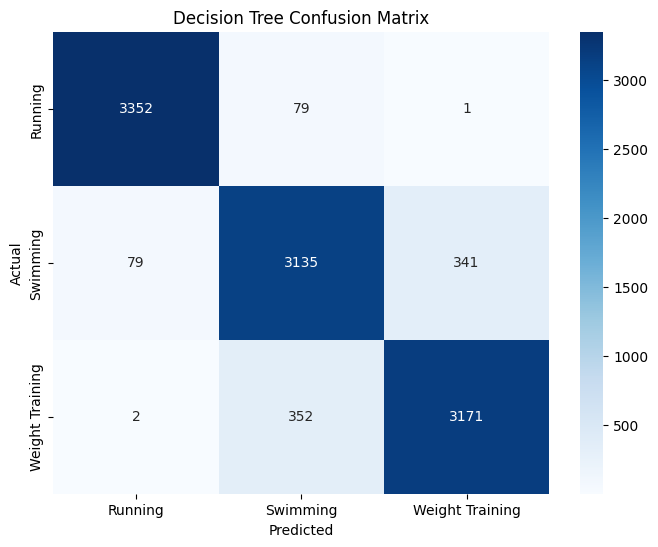

                 precision    recall  f1-score   support

        Running       0.98      0.98      0.98      3432
       Swimming       0.88      0.88      0.88      3555
Weight Training       0.90      0.90      0.90      3525

       accuracy                           0.92     10512
      macro avg       0.92      0.92      0.92     10512
   weighted avg       0.92      0.92      0.92     10512



In [ ]:
cm = confusion_matrix(y_test, y_pred_dtc)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names,
            yticklabels=activity_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_dtc, target_names=activity_names))

In [ ]:
from sklearn.metrics import accuracy_score

# Overall accuracy
acc = accuracy_score(y_test, y_pred_dtc)
misclass = 1 - acc

print(f"Accuracy:          {acc:.4f} ({acc*100:.2f}%)")
print(f"Misclassification: {misclass:.4f} ({misclass*100:.2f}%)")

Accuracy:          0.9188 (91.88%)
Misclassification: 0.0812 (8.12%)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Tuned Decision Tree Classifier
best_dtc = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=10,
    max_leaf_nodes=50,
    random_state=42,
    max_features=None,
    splitter="best",
    criterion="gini"
)

best_dtc.fit(X_train_scaled, y_train)
y_pred_best = best_dtc.predict(X_test_scaled)

print(f"Tuned Decision Tree accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=activity_names))

Tuned Decision Tree accuracy: 0.6624
                 precision    recall  f1-score   support

        Running       0.82      0.85      0.83      3432
       Swimming       0.54      0.48      0.51      3555
Weight Training       0.62      0.67      0.64      3525

       accuracy                           0.66     10512
      macro avg       0.66      0.66      0.66     10512
   weighted avg       0.66      0.66      0.66     10512



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

best_dtc = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_leaf_nodes=None,
    random_state=42,
    max_features=None,
    splitter="best",
    criterion="gini"
)

best_dtc.fit(X_train_scaled, y_train)
y_pred_best = best_dtc.predict(X_test_scaled)

print(f"Tuned Decision Tree accuracy: {accuracy_score(y_test, y_pred_best):.4f}")

Tuned Decision Tree accuracy: 0.9188


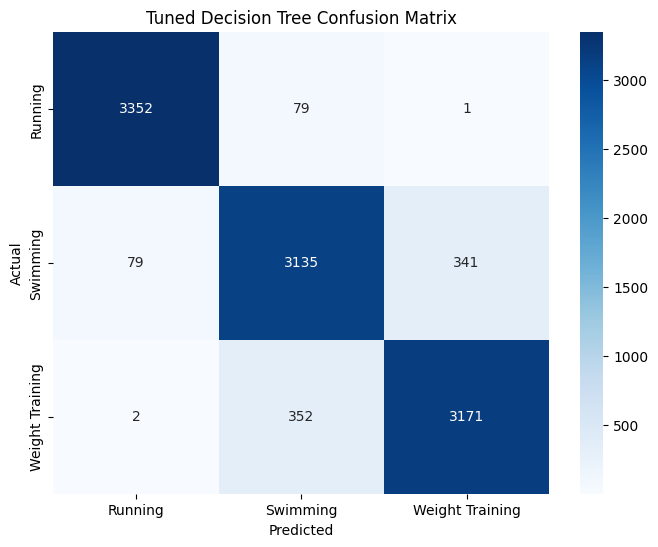

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names,
            yticklabels=activity_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Decision Tree Confusion Matrix')
plt.show()

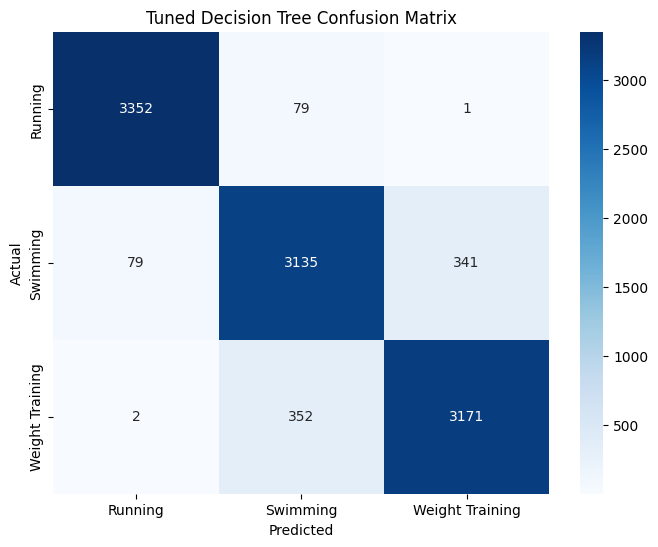

                 precision    recall  f1-score   support

        Running       0.98      0.98      0.98      3432
       Swimming       0.88      0.88      0.88      3555
Weight Training       0.90      0.90      0.90      3525

       accuracy                           0.92     10512
      macro avg       0.92      0.92      0.92     10512
   weighted avg       0.92      0.92      0.92     10512

Accuracy:          0.9188
Misclassification: 0.0812


In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names,
            yticklabels=activity_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Decision Tree Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_best, target_names=activity_names))
print(f"Accuracy:          {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Misclassification: {1 - accuracy_score(y_test, y_pred_best):.4f}")

 **Modeling Summary**   

**Baseline**

Logistic Regression was used as the baseline, as the starting point. Before fitting, all features were scaled to
ensure the model could converge properly. The baseline achieved
82% accuracy, with Running being the easiest to predict (91%
precision) and Swimming the hardest (75%).

**Model Comparison**

3 models were tested and compared using both tests accuracy and
cross-validation to ensure results were reliable and not simply
a product of how the data was split.


* KNN performed poorly at 0.5035 test accuracy and
was eliminated.
*  Random Forest achieved  0.8993 test
accuracy.
* The Decision Tree outperformed all other tests with an accuracy of 0.9188, and was selected as the final model  with a cross-validation mean of 91.47%, confirming the
performance was consistent.

**Decision Tree**

The Decision Tree  achieved
91.88% accuracy with only 8.12% misclassification. Hyperparameter
tuning was attempted but reduced accuracy to 66%, confirming
the default configuration was already well suited to the data.
The original model was retained.

**Confusion Matrix **

- Running: 98% precision and recall are the most distinct profile, nearly perfectly classified.
- Weight Training: 90%,  good performance with minor confusion.
- Swimming: 88%,  the weakest of the three. 341 actual swimmers
  were predicted as Weight Trainers, and 352 Weight Trainers
  were predicted as Swimmers.

The main confusion is between Swimming and Weight Training,
suggesting these two groups share overlapping behavioral and
health characteristics.

# Final Evaluation:

## Evaluation

**How do we know the model is good?**

For clustering, the silhouette score was used to validate the choice
of k=3. A score of 0.0784 is modest and indicates the clusters are
real but not sharply separated. This is expected with synthetic data
where variables are designed to be independent.

The clusters were
further validated by examining the centroid profiles, which revealed
meaningful and interpretable differences across workout behavior,
body composition, and consistency patterns.

For classification, four models were tested. KNN was eliminated
immediately at 50% accuracy essentially random guessing.
Logistic Regression served as the baseline at 82%. Random Forest
reached 89.93%. The Decision Tree came out on top at 91.88%.

Cross-validation was run across 5 folds to stress-test the result. The mean accuracy across all folds was 91.47%, almost identical to the 91.88% test accuracy. A gap that small confirms the model performs consistently on unseen data it is not just memorizing the training set.

Hyperparameter tuning was attempted on the Decision Tree to see
if performance could be improved further. It dropped accuracy to
66%, which confirmed the default configuration was already the
best fit for this data. The original model was retained.

Finally, the confusion matrix was examined. Running is predicted
with 98% precision, Weight Training sits
at 90%. Swimming is the weakest at 88%, with the main confusion
being between swimmers and weight trainers.


Given that the cost
of a wrong recommendation is low in this context, a person can
simply try another activity if not suitable, this level of performance is
acceptable and defensible.


**Limitations of the Model**

The dataset is synthetic. While it simulates realistic session-level
metrics, it does not reflect how real human behavior changes over
time  as confirmed by the weight change analysis, where all
participants gained weight uniformly across the year. A real
population would show far more variation.

The silhouette scores across all clustering attempts were low,
meaning the behavioral groups identified are real but not strongly
separated. In a real dataset with messier, more correlated variables,
the clusters might be more distinct or harder to find.

The 0.90 correlation threshold used to evaluate interaction terms
was a judgment call. A different threshold would have produced
different features and potentially different results.

Finally, the analysis is limited to three activities and one age
group. The model cannot generalize to other activities or age
ranges without being retrained.


# Conclusion

In this project, the goal was to find out if only the information about
behaviors and health indicators could recommend an appropriate type of physical activity to
a young adult person without taking into account his or her preferences.

The results show that yes, this can be done with a 91.88% accuracy and reliable cluster
characteristics that pass cross-validation.

But perhaps the most surprising part about the findings is that the accuracy score was not
the most intriguing outcome of this research. The reason for saying that is the similarity
of sleep, stress, and hydration variables that were supposed to differentiate clusters of
people according to their behaviors. The actual differentiating characteristics were the
intensity of training, weight, and regularity of attending workouts.

Another surprising finding is that Swimming and Weight Training people got confused in the
classifier due to having very similar health indicators. This means that there may be more
commonalities in their behaviors than one could expect initially.

Filtering to ages 18 to 30, setting an interaction term cutoff
at 0.90, picking k = 3, none all these decisions could have given different outcomes. Another analysis could have made other decisions and have a different set of clusters, a list of factors, and/or a different
outcome. This is admitted. But there was always a rationale
behind each decision, and when it could be tested, it was.

The data here is fabricated, so extrapolation from it
is necessarily limited. Human beings are not as predictable
as simulated characters. A real-world validation would be
the next necessary step before implementing any solution.

What this work demonstrates is that the two-stage process; first cluster, then classify to generate recommendations
provides a clean, sound basis for recommending tailored advice.